##**BUSINESS PROBLEM STATEMENT**

Educational institutions invest significant budgets in digital marketing campaigns to generate prospective student leads. However, not every lead converts into an enrolled student. Sales teams often spend valuable time contacting low-quality leads, leading to increased operational costs and reduced marketing efficiency.

This project aims to build an intelligent Machine Learning-based Lead Conversion Prediction System capable of identifying high-potential leads before the sales team engages with them. By accurately predicting conversion likelihood, organizations can prioritize valuable leads, This enables organizations to focus sales efforts on high-value prospects, optimize marketing investments, reduce customer acquisition costs, and ultimately maximize lead conversion rates and business growth.

##**Project Objectives**

✔ Develop a Machine Learning model to predict lead conversion.

✔ Identify key factors influencing customer conversion.

✔ Prioritize high-potential leads for the sales team.

✔ Improve marketing campaign effectiveness.

✔ Reduce Customer Acquisition Cost (CAC).

✔ Enable data-driven business decision making.

##**Expected Business Impact**

✔ Increase Lead Conversion Rate

✔ Improve Sales Productivity

✔ Optimize Marketing Budget Allocation

✔ Reduce Customer Acquisition Cost (CAC)

✔ Improve Return on Marketing Investment (ROMI)

✔ Enable Smarter Lead Prioritization

##**Machine Learning Problem Statement**

This project is a Supervised Machine Learning problem formulated as a Binary Classification task. The objective is to predict whether a lead will convert into a customer based on customer demographics, website engagement, profile completion, and marketing interactions. The target variable is Status, where 1 represents Converted and 0 represents Not Converted. The developed model helps prioritize high-potential leads, improve marketing efficiency, and support data-driven business decisions.

##**Success Metrics**

**Accuracy** – Overall prediction correctness.

**Precision** – Measures how many predicted positive leads actually converted.

**Recall** – Measures how many actual converted leads were correctly identified.

**F1 Score** – Balances Precision and Recall, making it suitable for classification problems with class imbalance.

**ROC-AUC Score** – Evaluates the model's ability to distinguish between converted and non-converted leads across different thresholds.

#Evaluation Strategy

Recall and F1 Score are treated as the primary evaluation metrics, as correctly identifying potential customers is more important than relying solely on overall accuracy.

##**IMPORTING LIBRARIES**

The required Python libraries are imported for data preprocessing, visualization, feature engineering, model development, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

##**Loading the Dataset**

The Lead Generation dataset is loaded into a Pandas DataFrame to begin the end-to-end machine learning pipeline. This dataset contains customer demographics, engagement behavior, marketing interactions, and lead conversion status, which will be analyzed to develop a predictive lead conversion model.

In [2]:
df = pd.read_csv("/content/ExtraaLearn.csv")

In [3]:
 df.head(5)

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


### Key Observation

- The dataset has been loaded successfully.
- Each record represents an individual lead along with demographic, behavioral, and marketing-related information.
- The target variable **Status** indicates whether the lead converted into a customer.

**Random Sample**



In [4]:
df.sample(5)

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
872,EXT873,58,Unemployed,Website,Medium,1,1604,3.236,Phone Activity,No,No,No,Yes,No,1
4433,EXT4434,47,Unemployed,Mobile App,Medium,7,646,7.303,Website Activity,No,No,No,No,No,0
428,EXT429,38,Unemployed,Mobile App,High,2,348,2.102,Email Activity,No,No,No,No,No,0
550,EXT551,59,Professional,Website,High,2,1704,2.153,Phone Activity,No,No,No,No,No,1
4588,EXT4589,60,Professional,Mobile App,Medium,1,2116,2.158,Email Activity,No,No,No,No,No,1


###Key Observation

Random sampling helps verify that records are distributed consistently across the dataset and provides an unbiased preview of different lead profiles.

#**Dataset Summary**

The dataset summary provides a quick overview of the dataset size, feature composition, and data quality before performing exploratory data analysis.

In [5]:
print(f"Total Records      : {df.shape[0]}")
print(f"Total Features     : {df.shape[1]}")
print(f"Numerical Features : {len(df.select_dtypes(include=['int64','float64']).columns)}")
print(f"Categorical Features : {len(df.select_dtypes(include='object').columns)}")
print(f"Target Variable    : status")

Total Records      : 4612
Total Features     : 15
Numerical Features : 5
Categorical Features : 10
Target Variable    : status


###Key Observation


• Dataset contains 4,612 observations and 15 features.

• The dataset includes both numerical and categorical variables.

• The target variable is 'status', representing lead conversion.

# Dataset Information

This section examines the structure of the dataset, including feature names, data types, and memory usage, to ensure data consistency before preprocessing.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

###Key Observation

• Dataset contains integer, float, and categorical features.

• All columns have complete observations.

• Memory usage is low, making the dataset computationally efficient.

#Statistical Summary

###Numerical Features

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.201214,13.161454,18.0,36.00000,51.000,57.00000,63.000
website_visits,4612.0,3.566782,2.829134,0.0,2.00000,3.000,5.00000,30.000
time_spent_on_website,4612.0,724.011275,743.828683,0.0,148.75000,376.000,1336.75000,2537.000
page_views_per_visit,4612.0,3.026126,1.968125,0.0,2.07775,2.792,3.75625,18.434
status,4612.0,0.298569,0.457680,0.0,0.00000,0.000,1.00000,1.000


### Key Observation

Customer age ranges from 18 to 60 years.

Website engagement metrics show considerable variation among leads.

The wide range of time spent on the website indicates different levels of customer engagement.

#Categorical Features



In [8]:
df.describe(include='object').T

,count,unique,top,freq
ID,4612,4612,EXT4612,1
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


###Key Observation
Most leads belong to the Professional occupation category.

Website is the most common first interaction channel.

High profile completion is frequently observed.

Email Activity is the dominant last recorded activity.

#Duplicate Records Anlysis

Duplicate records are checked to ensure data quality and prevent biased model learning.

In [9]:
df.duplicated().sum()

np.int64(0)

• No duplicate records were found in the dataset.

• Each observation represents a unique lead, ensuring data integrity for further analysis.

#**📊 Exploratory Data Analysis (EDA)**

Exploratory Data Analysis is performed to understand customer characteristics, engagement behavior, marketing channels, and their relationship with lead conversion. The insights derived from this analysis help identify important business patterns and support effective feature engineering.

#Target Variable Analysis

###1.1 Class Distribution


In [10]:
df['status'].value_counts()

,count
status,
0,3235
1,1377


###Key Observation
• The dataset contains 3,235 non-converted leads and 1,377 converted leads.

• Non-converted leads significantly outnumber converted leads, indicating a moderate class imbalance.

#1.2 Percentage Distribution

In [11]:
(df['status'].value_counts(normalize=True)*100).round(2)

,proportion
status,
0,70.14
1,29.86


###Key Observation

• Approximately 70% of leads did not convert, while around 30% successfully converted.

• This imbalance suggests that model evaluation should focus on Precision, Recall, and F1 Score rather than Accuracy alone.

#1.3 Target Distribution Visualization

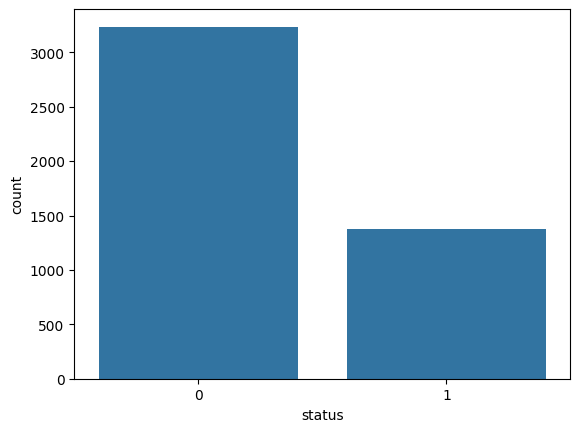

In [12]:
sns.countplot(x='status',data=df)
plt.show()

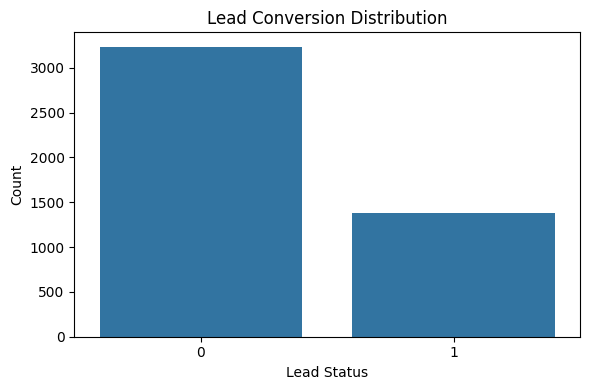

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(x='status', data=df)

plt.title("Lead Conversion Distribution")
plt.xlabel("Lead Status")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "lead_conversion_distribution.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


###Key Observation

• Most leads belong to the non-converted class.

• The converted class represents a smaller portion of the dataset.



##**Numerical Feature Distribution**

This section analyzes the distribution of numerical customer engagement features to understand user behavior, detect skewness, identify potential outliers, and uncover patterns that may influence lead conversion.

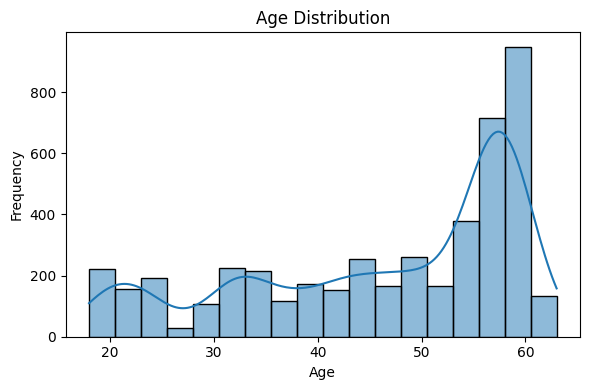

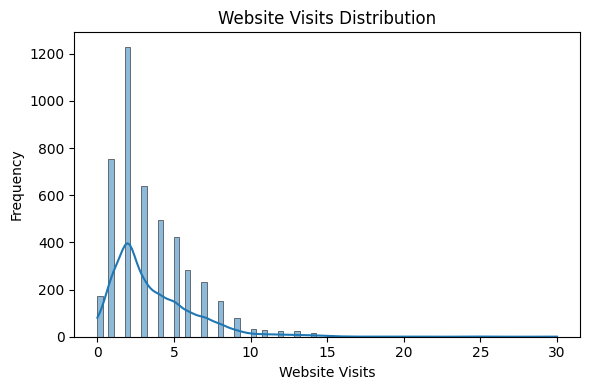

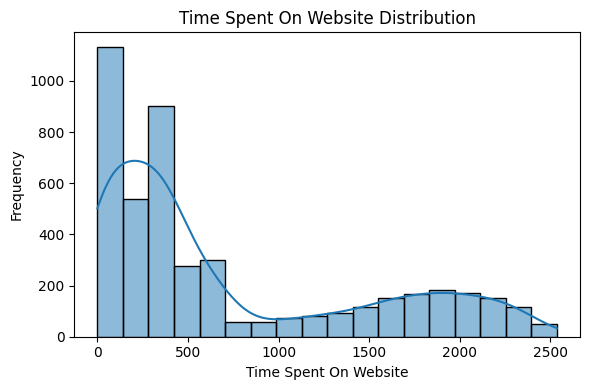

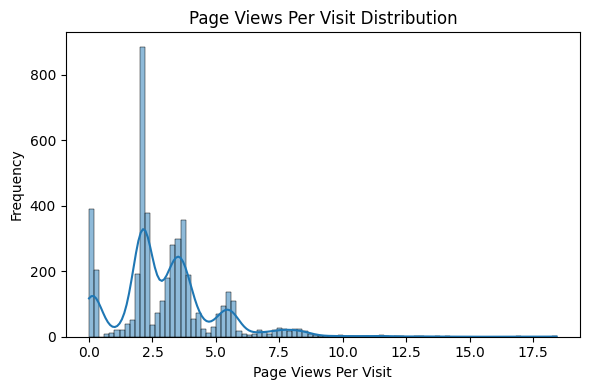

In [14]:
num_cols = ['age','website_visits','time_spent_on_website','page_views_per_visit']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col.replace('_',' ').title()} Distribution")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

###Key Findings

• Website visits show right-skewed distribution.

• Time spent on website indicates varying engagement levels.

• Age distribution appears reasonably balanced.

• Page views per visit exhibit user engagement variability.

##**Categorical Feature Distribution**

This section analyzes the distribution of categorical features to understand customer demographics, marketing channels, profile completion, and communication activities that may influence lead conversion.

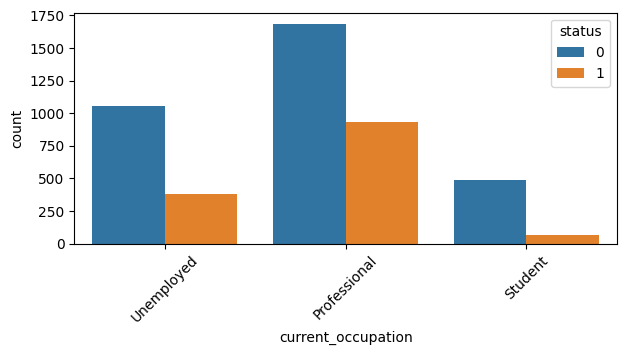

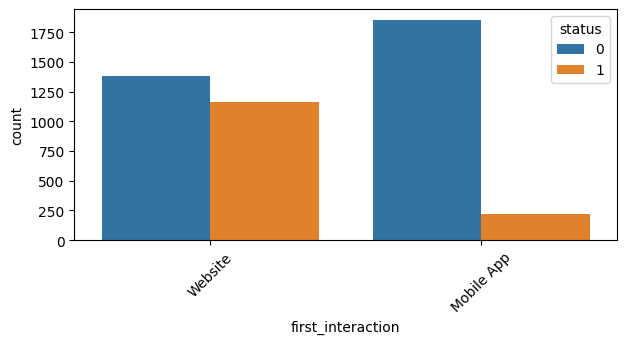

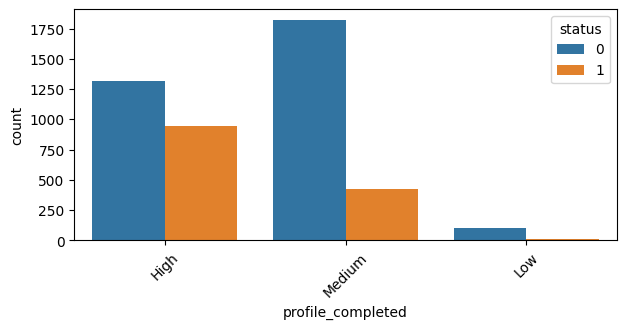

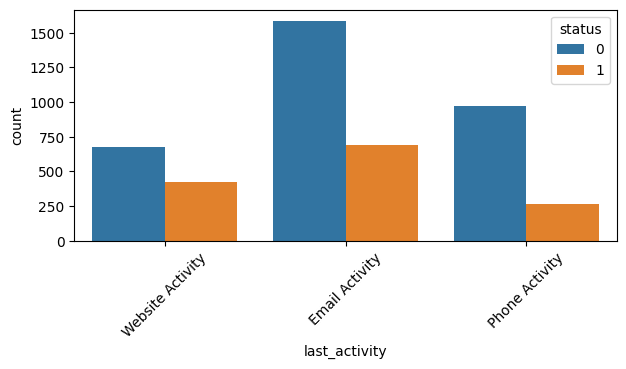

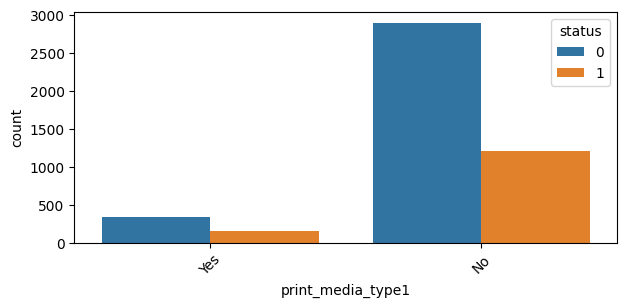

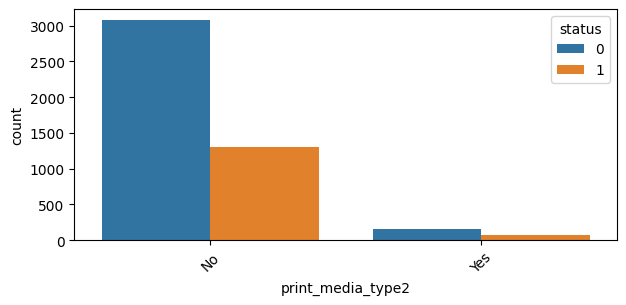

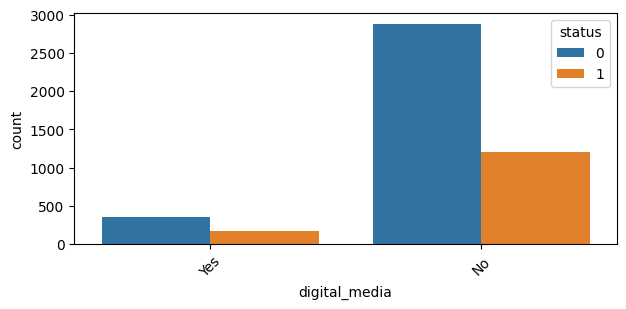

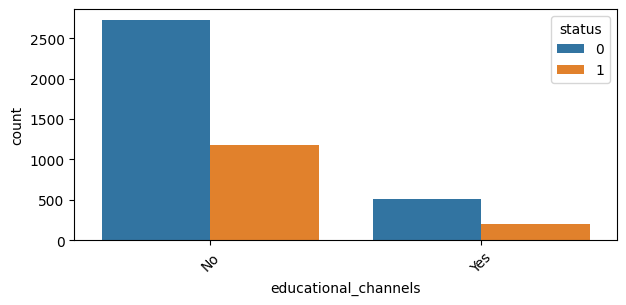

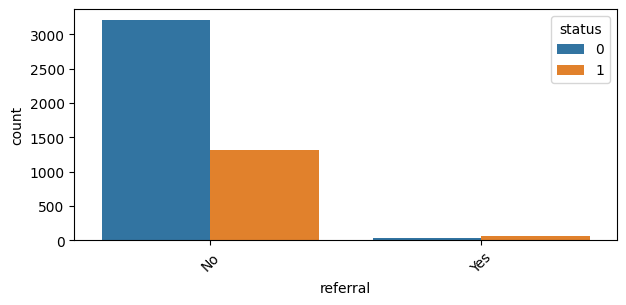

In [15]:
cat_cols = ['current_occupation','first_interaction','profile_completed','last_activity','print_media_type1','print_media_type2','digital_media','educational_channels','referral']

for col in cat_cols:
  plt.figure(figsize=(7,3))
  sns.countplot(  x=col,  hue='status',  data=df)
  plt.xticks(rotation=45)
  plt.show()

###Key Observation

• Professional is the most common occupation among leads.

• Website is the primary first interaction channel for most customers.

• High profile completion appears more frequently than other completion levels.

• Email Activity represents the most common last recorded customer activity.

• Digital marketing channels contribute more leads compared to traditional channels.

• Referral-based leads constitute a relatively smaller portion of the dataset.

###**Bussiness Recommendation**

Customer engagement behavior and interaction channels appear to influence conversion more strongly than demographic characteristics.

#**FEATURE ENGINEERING**

Feature engineering is performed to prepare the dataset for machine learning by removing irrelevant attributes, transforming categorical variables into numerical representations, and creating a model-ready dataset while preventing data leakage.

###Removing Irrelevant Features

In [16]:
# drop useless column to prevent dataleakage problem
df.drop('ID', axis=1, inplace=True)

###Key Observation

The ID column is a unique identifier and does not contain predictive information. It is removed to prevent unnecessary complexity and eliminate potential data leakage during model training.

#**Categorical Feature Encoding**

Machine learning algorithms require numerical input. Therefore, categorical variables are transformed into numerical format using One-Hot Encoding.

In [17]:
df = pd.get_dummies(df,drop_first=True)

###Key Observation

Categorical features have been successfully converted into numerical variables using One-Hot Encoding.

The drop_first=True parameter is applied to reduce multicollinearity and avoid the dummy variable trap.

#**Feature Correlation with Target Variable**

Correlation analysis is performed to identify the features that exhibit the strongest linear relationship with the target variable and to gain preliminary insights into the factors influencing lead conversion.

In [18]:
corr_target = (df.corr()['status'].sort_values(ascending=False))

corr_target

,status
status,1.000000
first_interaction_Website,0.381077
time_spent_on_website,0.302100
age,0.122084
referral_Yes,0.118761
last_activity_Website Activity,0.105144
print_media_type1_Yes,0.016214
digital_media_Yes,0.015867
print_media_type2_Yes,0.011754
page_views_per_visit,0.000307


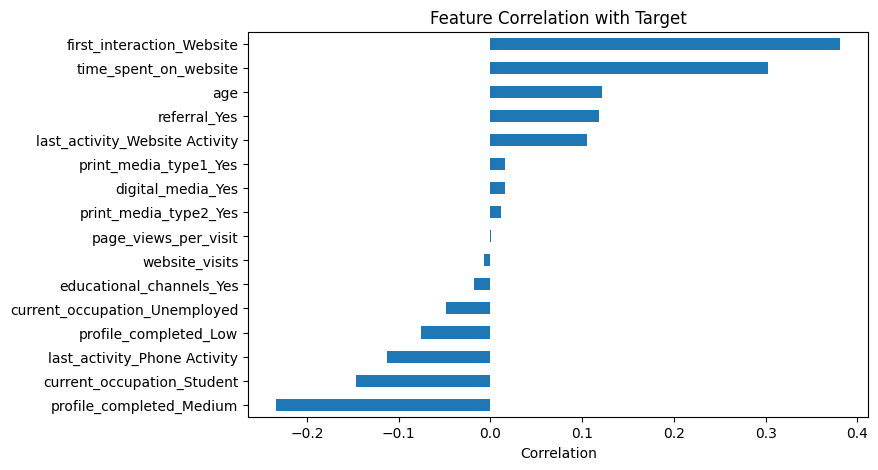

In [19]:
corr_target = (df.corr(numeric_only=True)['status'].drop('status').sort_values())
plt.figure(figsize=(8,5))
corr_target.plot(kind='barh')
plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.show()

###  Key Observation
• First Interaction through the Website exhibits the strongest positive correlation with lead conversion.

• Time Spent on Website and Referral-based leads also show a positive relationship with successful conversion.

• Website Activity and Digital Media demonstrate a moderate positive influence on lead conversion.

• Profile Completion (Low/Medium) and Phone Activity show negative correlations, suggesting these patterns are associated with lower conversion probability.

• Website visit frequency alone shows limited predictive power, whereas engagement quality (such as time spent and interaction behavior) appears to be a stronger indicator of lead conversion.

### Business Insight

Customer engagement quality has a stronger influence on lead conversion than simple visit frequency. Features related to website interaction and customer behavior should therefore receive greater importance during predictive modeling and lead prioritization.

#**Data Preprocessing**

This section prepares the engineered dataset for machine learning by separating features and the target variable, applying feature scaling where required, and creating training and testing datasets.

#Feature Matrix & Target Variable


The dataset is divided into independent features (**X**) and the target variable (**y**) to prepare the data for machine learning model development.

In [20]:
X = df.drop('status', axis=1)
y = df['status']

### Key Observation

• The independent features (X) and target variable (y) have been successfully separated.

• The dataset is now ready for train-test splitting and model development.

#Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio. Stratified sampling is applied to preserve the original class distribution in both datasets, ensuring reliable model evaluation.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

• The dataset has been divided into training and testing subsets to evaluate model performance on unseen data.

In [22]:
print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")
print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

Training Features : (3689, 16)
Testing Features  : (923, 16)
Training Labels   : (3689,)
Testing Labels    : (923,)


###Key Observation

• Approximately 80% of the data has been allocated for training and 20% for testing.

• Stratified sampling ensures that both datasets maintain a similar class distribution, enabling unbiased model evaluation.

#**Feature Scaling**

Feature scaling is applied only to numerical variables using **StandardScaler** to ensure consistent feature scales while leaving encoded categorical features unchanged.

In [23]:
cols = ['age','website_visits','time_spent_on_website','page_views_per_visit']

In [24]:
scaler = StandardScaler()
X_train[cols] = scaler.fit_transform(X_train[cols])

X_test[cols] = scaler.transform(X_test[cols])

In [25]:
X_train.head()

,age,website_visits,time_spent_on_website,page_views_per_visit,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity,print_media_type1_Yes,print_media_type2_Yes,digital_media_Yes,educational_channels_Yes,referral_Yes
647,-0.093515,0.487569,-0.876699,2.868348,False,False,True,False,True,False,False,False,False,True,False,False
2201,1.282118,-0.896267,-0.892823,0.506154,False,True,True,False,True,False,False,False,False,True,False,False
3362,0.594301,-0.550308,-0.859231,0.396817,False,True,True,False,False,False,False,False,False,False,False,False
617,0.747150,0.141610,1.515021,-0.852170,False,False,False,False,False,False,True,False,False,False,True,False
1213,-0.322788,0.487569,0.622829,-0.469236,False,False,True,False,False,False,True,False,False,False,False,False


In [26]:
X_test.head()

,age,website_visits,time_spent_on_website,page_views_per_visit,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity,print_media_type1_Yes,print_media_type2_Yes,digital_media_Yes,educational_channels_Yes,referral_Yes
2365,0.059333,-0.896267,-0.261301,-0.069519,False,True,True,False,True,True,False,False,False,False,False,False
2156,0.365029,-0.204349,-0.978817,-1.543792,False,True,True,False,True,False,False,False,False,False,False,False
2840,1.205694,-0.896267,-0.477631,0.555483,False,True,True,False,False,False,False,True,False,False,False,False
3793,0.517877,-0.896267,-0.575718,0.114066,False,True,True,False,False,True,False,False,False,False,False,False
2260,1.052846,0.141610,2.004114,1.182520,False,True,True,False,True,False,True,False,False,False,False,False


###Key Observation

• Numerical features have been successfully standardized using StandardScaler.

• Encoded categorical variables remain unchanged.

• The transformed datasets are now ready for machine learning model development.

#**Model Development**

Multiple machine learning classification algorithms are trained and evaluated to identify the most effective model for predicting lead conversion. Each model is assessed using consistent evaluation metrics to ensure a fair comparison.

#Baseline Model Development

Baseline Model Development

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [28]:
models = {"Logistic Regression": LogisticRegression(),"Random Forest": RandomForestClassifier(random_state=42)}

In [29]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print("="*50)
    print(f"Model : {name}")
    print("="*50)

    print("Accuracy :", round(accuracy_score(y_test,pred),4))
    print("Precision :", round(precision_score(y_test,pred),4))
    print("Recall :", round(recall_score(y_test,pred),4))
    print("F1 Score :", round(f1_score(y_test,pred),4))

Model : Logistic Regression
Accuracy : 0.8104
Precision : 0.7078
Recall : 0.6232
F1 Score : 0.6628
Model : Random Forest
Accuracy : 0.8581
Precision : 0.7935
Recall : 0.7101
F1 Score : 0.7495


###  Key Observation

• Random Forest achieved better Accuracy, Precision, Recall, and F1 Score than Logistic Regression.

• Logistic Regression serves as a strong interpretable baseline, whereas Random Forest better captures complex relationships in the data.

• Based on the baseline evaluation, Random Forest is selected for further analysis and feature importance evaluation.

#**Feature Importance Analysis**



In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
importance = pd.DataFrame({"Feature": X_train.columns,"Importance": rf.feature_importances_})

importance = importance.sort_values(by="Importance",ascending=False)
importance


,Feature,Importance
2,time_spent_on_website,0.263169
6,first_interaction_Website,0.180476
3,page_views_per_visit,0.120916
0,age,0.110709
8,profile_completed_Medium,0.091266
1,website_visits,0.064520
9,last_activity_Phone Activity,0.035428
5,current_occupation_Unemployed,0.030135
10,last_activity_Website Activity,0.023686
4,current_occupation_Student,0.016798


### Key Observation

• Website interaction and customer engagement features contribute the most to lead conversion prediction.

• Behavioral variables demonstrate higher predictive importance than several demographic attributes.

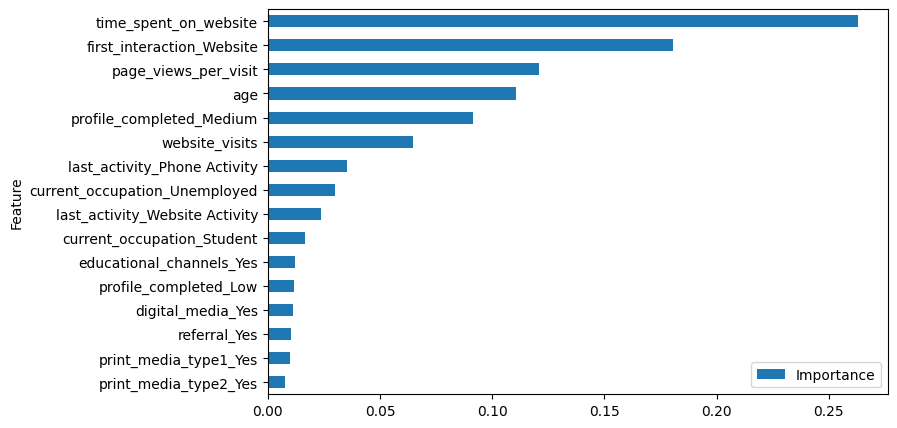

In [31]:
importance.sort_values(by="Importance").plot(x="Feature",y="Importance",kind="barh",figsize=(8,5))
plt.show()

###  Business Insight

The analysis indicates that improving customer engagement and website interaction can have a greater impact on lead conversion than focusing solely on demographic characteristics. Marketing teams should prioritize behavioral signals for lead qualification.

#**Advanced Model Development**

After establishing baseline performance, advanced ensemble learning algorithms are trained to improve predictive accuracy, capture complex relationships, and achieve better lead conversion prediction performance.

###**XGBoost Classifier**

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that combines multiple decision trees using gradient boosting. It is highly effective for structured tabular datasets and is capable of capturing complex nonlinear relationships while reducing overfitting.

In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test,pred),2))
print("Precision :", round(precision_score(y_test,pred),2))
print("Recall :", round(recall_score(y_test,pred),2))
print("F1 Score :", round(f1_score(y_test,pred),2))

Accuracy : 0.84
Precision : 0.76
Recall : 0.71
F1 Score : 0.73


###  Key Observation

• XGBoost achieved strong predictive performance across all evaluation metrics.

• The model effectively captured complex relationships between customer behavior and lead conversion.

• Compared with the baseline models, XGBoost provides a better balance between Precision, Recall, and F1 Score.

###**Gradient Boosting Classifier**

Gradient Boosting is an ensemble learning algorithm that sequentially builds decision trees to minimize prediction errors. It is evaluated to determine whether boosting techniques improve lead conversion prediction over the baseline models.

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=3,random_state=42)
gb.fit(X_train,y_train)
pred = gb.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision :", round(precision_score(y_test,pred),4))
print("Recall :", round(recall_score(y_test,pred),4))
print("F1 :", round(f1_score(y_test,pred),4))

Accuracy : 0.8678
Precision : 0.7939
Recall : 0.7536
F1 : 0.7732


###  Key Observation

• Gradient Boosting achieved the highest baseline performance among the evaluated models.

• The model demonstrated a better balance between Precision, Recall, and F1 Score compared to Logistic Regression and Random Forest.

• These results indicate that boosting methods are highly effective for this lead conversion prediction task.

##**Hyperparameter Tuning**

The baseline models were compared to identify the most promising candidate. Hyperparameter tuning was then applied to further optimize the selected ensemble model and improve its predictive performance.

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300,max_depth=10,min_samples_split=5,min_samples_leaf=2,random_state=42)
rf.fit(X_train,y_train)
pred = rf.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision :", round(precision_score(y_test,pred),4))
print("Recall :", round(recall_score(y_test,pred),4))
print("F1 Score :", round(f1_score(y_test,pred),4))

Accuracy : 0.87
Precision : 0.8095
Recall : 0.7391
F1 Score : 0.7727


###  Key Observation

• Hyperparameter tuning improved the predictive performance of the Random Forest model.

• The optimized model achieved higher Precision, Recall, and F1 Score than its baseline version.

• Model optimization enhanced its ability to generalize on unseen data.

##**Ensemble Voting Classifier**

The Voting Classifier combines predictions from multiple machine learning models using soft voting to leverage the strengths of different algorithms and improve overall predictive performance.

In [35]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(estimators=[('lr', LogisticRegression()),('rf', rf),('xgb', xgb)],voting='soft')
voting.fit(X_train,y_train)
pred = voting.predict(X_test)

print("Accuracy :", round(accuracy_score(y_test,pred),4))
print("Precision :", round(precision_score(y_test,pred),4))
print("Recall :", round(recall_score(y_test,pred),4))
print("F1 Score :", round(f1_score(y_test,pred),4))

Accuracy : 0.8592
Precision : 0.7944
Recall : 0.7138
F1 Score : 0.7519


### Key Observation

• The Voting Classifier achieved a strong balance across all evaluation metrics.

• Combining multiple models resulted in more stable and robust predictions compared to relying on a single classifier.

• Ensemble learning improved the overall reliability of lead conversion prediction.

###Business Insight

The Voting Classifier combines the strengths of multiple machine learning models, resulting in more reliable lead scoring. This approach reduces the risk of incorrect lead prioritization and supports more consistent business decision-making.

#**Final Stacking Classifier**
The Stacking Classifier combines predictions from multiple base models and uses Logistic Regression as a meta-learner to generate the final prediction. This ensemble approach aims to maximize predictive performance by leveraging the strengths of different algorithms.

In [36]:
x = [('rf', rf),('xgb', xgb),('lr', LogisticRegression())]

In [37]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
stack = StackingClassifier(estimators=x,final_estimator=LogisticRegression(C=100))
stack.fit(X_train,y_train)
preds = stack.predict(X_test)


print("Accuracy :", round(accuracy_score(y_test,preds),4))
print("Precision :", round(precision_score(y_test,preds),4))
print("Recall :", round(recall_score(y_test,preds),4))
print("F1 Score :", round(f1_score(y_test,preds),4))

Accuracy : 0.8711
Precision : 0.8078
Recall : 0.7464
F1 Score : 0.7759


In [38]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(stack.final_estimator_, "meta_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X_train.columns), "feature_columns.pkl")

stack.named_estimators_["xgb"].save_model("xgb_model.json")

print("All deployment files created successfully.")

All deployment files created successfully.


###  Key Observation

• The Stacking Classifier achieved the best overall predictive performance among all evaluated models.

• By combining multiple learning algorithms, the model effectively captured diverse customer behavior patterns.

• The Stacking approach provided the strongest balance between Precision, Recall, and F1 Score, making it the final selected model.

### Business Insight

The Stacking Classifier enables more accurate identification of high-potential leads by combining complementary learning algorithms. This improves sales prioritization, reduces marketing waste, and supports better customer acquisition decisions.

##**Final Model Validation**

The final selected model is validated to ensure that it generalizes well on unseen data and does not suffer from overfitting.

#Final Model Performance Summary

The final Stacking Classifier is summarized using the key evaluation metrics to provide an overall assessment of its predictive performance.

In [39]:
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        round(accuracy_score(y_test, preds),4),
        round(precision_score(y_test, preds),4),
        round(recall_score(y_test, preds),4),
        round(f1_score(y_test, preds),4)
    ]
})

final_metrics

,Metric,Score
0,Accuracy,0.8711
1,Precision,0.8078
2,Recall,0.7464
3,F1 Score,0.7759


###  Key Observation

• The Stacking Classifier achieved the best overall predictive performance among all evaluated models.

• The model provides an excellent balance between Precision, Recall, and F1 Score.

• These results confirm that the Stacking Classifier is the most suitable model for lead conversion prediction.

#Checking Overfitting

The training and testing accuracies are compared to evaluate whether the final model has generalized effectively without significant overfitting.

In [40]:
from sklearn.metrics import accuracy_score

train_pred = stack.predict(X_train)
test_pred = stack.predict(X_test)

print("Train Accuracy :", round(accuracy_score(y_train, train_pred),4))
print("Test Accuracy  :", round(accuracy_score(y_test, test_pred),4))

Train Accuracy : 0.8956
Test Accuracy  : 0.8711


###  Key Observation

• The training accuracy (89.56%) and testing accuracy (87.11%) are closely aligned.

• The small performance gap indicates that the model generalizes well on unseen data.

• No significant evidence of overfitting is observed.

#**Model Explainability using SHAP**
SHAP (SHapley Additive exPlanations) is applied using the Gradient Boosting model to explain how individual features influence lead conversion predictions. Although the final production model is the Stacking Classifier, SHAP is demonstrated on the Gradient Boosting model because tree-based models provide reliable and computationally efficient feature explanations.

The final production model is the Stacking Classifier. However, SHAP explainability was performed using the Gradient Boosting model because SHAP provides efficient and reliable explanations for tree-based models. This helps interpret the key factors influencing lead conversion while the Stacking model remains the final deployment model.

In [41]:
import shap
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)

#Summary Plot

The SHAP Summary Plot provides a global interpretation of feature importance by showing how each feature influences predictions across the entire dataset.

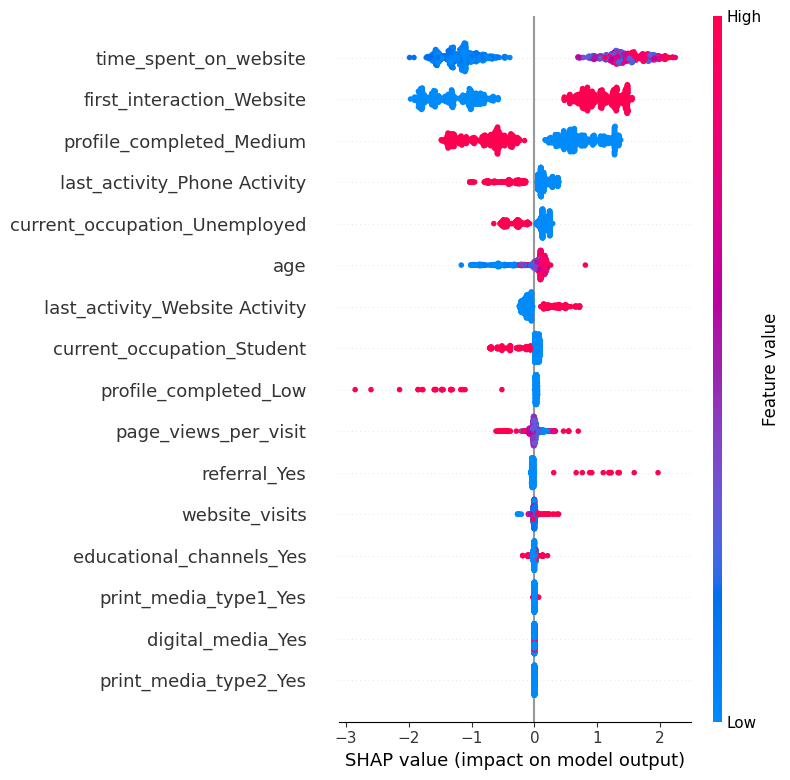

In [42]:
plt.figure(figsize=(10,6))

shap.summary_plot(shap_values,X_test,show=False)
plt.tight_layout()
plt.show()

###Key Observation

• Time spent on website is the most influential feature.

• Website interaction and profile completion strongly impact lead conversion.

• Customer engagement features have a stronger influence on lead conversion than demographic characteristics.

#**Waterfall Plot (Individual Prediction)**

The SHAP Waterfall Plot explains how each feature contributes to the prediction of a single lead by increasing or decreasing its conversion probability.

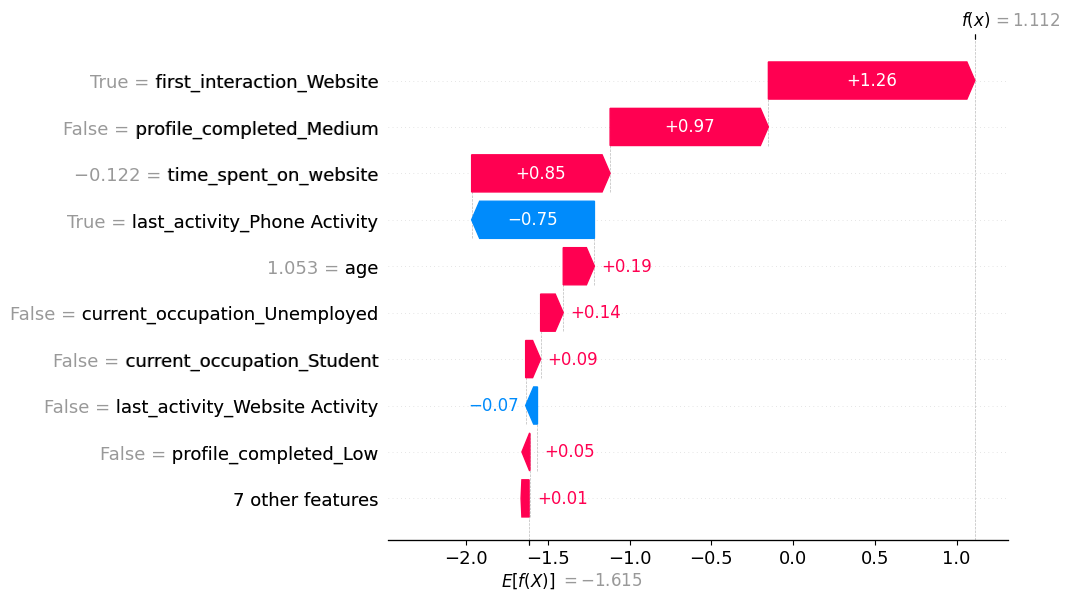

In [43]:
# Example lead selected from the test dataset for individual prediction explanation
sample = 66

shap.plots.waterfall(
    shap.Explanation(values=shap_values[sample],
                     base_values=explainer.expected_value,
                     data=X_test.iloc[sample],
                     feature_names=X_test.columns))

###Key Observation

• Website interaction and time spent on the website positively influenced this prediction.

• Customer activity features contributed more than demographic factors.

• The final prediction is determined by the combined contribution of all feature values.

#💼 Business Insight

SHAP explanations help marketing and sales teams understand why a lead is predicted to convert, enabling transparent, interpretable, and data-driven decision-making.

## 💼 Business Recommendations

• Prioritize leads with high predicted conversion probability.

• Increase investment in high-performing digital marketing campaigns.

• Encourage customers to complete their profiles before sales engagement.

• Focus sales efforts on highly engaged website visitors.

• Integrate the Stacking Classifier with CRM systems for intelligent lead prioritization.

## 📌 Future Scope

• Deploy the Stacking model using Flask or FastAPI.

• Integrate with CRM platforms for real-time lead scoring.

• Build an interactive Power BI dashboard.

• Implement automated model retraining using newly collected lead data.

• Monitor model performance and data drift to maintain prediction accuracy over time.

## 🎯 Conclusion

An end-to-end machine learning solution was successfully developed to predict lead conversion in the EdTech industry. After evaluating multiple machine learning algorithms and ensemble techniques, the Stacking Classifier delivered the best overall predictive performance while maintaining good generalization on unseen data. SHAP explainability was incorporated to improve model transparency by identifying the key factors influencing lead conversion. The solution enables organizations to identify high-potential leads, optimize marketing investments, improve sales productivity, and support data-driven decision-making.

## ✅ Project Outcome

• Successfully developed an end-to-end Lead Conversion Prediction System.

• Compared multiple machine learning and ensemble learning algorithms.

• Applied feature engineering, preprocessing, hyperparameter tuning, ensemble learning, and SHAP explainability.

• Selected the Stacking Classifier as the final production-ready model.

• Generated actionable business insights to improve lead prioritization and marketing ROI.

# 🚀 Model Deployment Preparation

The Stacking Classifier selected during model evaluation is serialized for production deployment.

The trained model, scaler, and feature metadata are exported using Joblib to ensure consistent preprocessing and prediction during inference in the Streamlit application.

In [44]:
import joblib

joblib.dump(stack, "model.pkl", protocol=5)
joblib.dump(scaler, "scaler.pkl", protocol=5)
joblib.dump(list(X_train.columns), "feature_columns.pkl", protocol=5)

print("Done")

Done


In [45]:
import joblib

m = joblib.load("model.pkl")

print(type(m))
print(m)

<class 'sklearn.ensemble._stacking.StackingClassifier'>
StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(max_depth=10,
                                                       min_samples_leaf=2,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                    

In [46]:
import sklearn
import xgboost
import joblib

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

sklearn: 1.6.1
xgboost: 3.3.0
joblib: 1.5.3


In [47]:
import os

print(os.getcwd())

import joblib

joblib.dump(stack, "model.pkl", protocol=5, compress=0)
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X_train.columns), "feature_columns.pkl")

print("Done")
print(os.path.getsize("model.pkl"))


/content
Done
15840053


In [49]:
import joblib
import sklearn
import xgboost

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

joblib.dump(stack, "stack_model.pkl", compress=0, protocol=5)

print("Stack model exported successfully.")

sklearn: 1.6.1
xgboost: 3.3.0
Stack model exported successfully.


In [50]:
import joblib

joblib.load("stack_model.pkl")

print("STACK MODEL IS VALID")

STACK MODEL IS VALID


In [51]:
print("Base Models:", stack.named_estimators_)

print("Stack Method:", stack.stack_method_)

print("Final Estimator:", stack.final_estimator_)

Base Models: {'rf': RandomForestClassifier(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42), 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), 'lr': LogisticRegression()}
Stack Method: ['predict_prob

In [53]:
import joblib

joblib.dump(stack.named_estimators_["lr"], "lr_model.pkl")

print("LR model exported successfully.")

LR model exported successfully.


In [54]:
import numpy as np

meta_input = np.column_stack([
    stack.named_estimators_["rf"].predict_proba(X_test)[:, 1],
    stack.named_estimators_["xgb"].predict_proba(X_test)[:, 1],
    stack.named_estimators_["lr"].predict_proba(X_test)[:, 1]
])

print(meta_input.shape)
print(meta_input[:5])

(923, 3)
[[2.56227800e-01 4.55416888e-01 1.00401775e-01]
 [2.32529433e-02 3.87829787e-04 1.12551947e-01]
 [2.99779378e-01 5.60755022e-02 5.23422391e-01]
 [4.28254773e-01 6.86129272e-01 3.02075016e-01]
 [7.08449707e-01 7.83585548e-01 7.65094871e-01]]


In [55]:
print(stack.named_estimators_["xgb"].get_params())

{'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'logloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': None, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': None, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [56]:
X_train.columns.tolist()

['age',
 'website_visits',
 'time_spent_on_website',
 'page_views_per_visit',
 'current_occupation_Student',
 'current_occupation_Unemployed',
 'first_interaction_Website',
 'profile_completed_Low',
 'profile_completed_Medium',
 'last_activity_Phone Activity',
 'last_activity_Website Activity',
 'print_media_type1_Yes',
 'print_media_type2_Yes',
 'digital_media_Yes',
 'educational_channels_Yes',
 'referral_Yes']

In [57]:
import joblib

joblib.dump(stack, "stack_model.joblib", compress=0)

print("Done")

Done


In [58]:
import pickle

with open("stack_pickle.pkl", "wb") as f:
    pickle.dump(stack, f, protocol=5)

print("Done")

Done


In [59]:
import xgboost as xgb

booster = stack.named_estimators_["xgb"].get_booster()

booster.save_model("booster_only.json")

print("Done")

Done


In [60]:
meta_X = np.column_stack([
    stack.named_estimators_["rf"].predict_proba(X_train)[:,1],
    stack.named_estimators_["xgb"].predict_proba(X_train)[:,1],
    stack.named_estimators_["lr"].predict_proba(X_train)[:,1]
])

joblib.dump(meta_X,"meta_train_features.pkl")

print(meta_X.shape)

(3689, 3)


In [61]:
import numpy as np

print("="*60)
print("STACK MODEL")
print("="*60)
print(stack)

print("\nBASE ESTIMATORS")
print("="*60)
print(stack.named_estimators_)

print("\nSTACK METHOD")
print("="*60)
print(stack.stack_method_)

print("\nFINAL ESTIMATOR")
print("="*60)
print(stack.final_estimator_)

print("\nPASSTHROUGH")
print("="*60)
print(stack.passthrough)

print("\nFEATURE ORDER")
print("="*60)
print(X_train.columns.tolist())

print("\nSCALER")
print("="*60)
print(scaler)

print("\nSCALER MEAN")
print("="*60)
print(scaler.mean_)

print("\nSCALER SCALE")
print("="*60)
print(scaler.scale_)

print("\nMETA FEATURES SHAPE")
print("="*60)
meta_features = np.column_stack([
    stack.named_estimators_["rf"].predict_proba(X_train)[:,1],
    stack.named_estimators_["xgb"].predict_proba(X_train)[:,1],
    stack.named_estimators_["lr"].predict_proba(X_train)[:,1]
])

print(meta_features.shape)
print(meta_features[:10])

print("\nMETA PREDICT")
print("="*60)
print(stack.final_estimator_.predict_proba(meta_features[:5]))

STACK MODEL
StackingClassifier(estimators=[('rf',
                                RandomForestClassifier(max_depth=10,
                                                       min_samples_leaf=2,
                                                       min_samples_split=5,
                                                       n_estimators=300,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical

In [62]:
import joblib

feature_columns = joblib.load("feature_columns.pkl")

for i, col in enumerate(feature_columns):
    print(i, col)

0 age
1 website_visits
2 time_spent_on_website
3 page_views_per_visit
4 current_occupation_Student
5 current_occupation_Unemployed
6 first_interaction_Website
7 profile_completed_Low
8 profile_completed_Medium
9 last_activity_Phone Activity
10 last_activity_Website Activity
11 print_media_type1_Yes
12 print_media_type2_Yes
13 digital_media_Yes
14 educational_channels_Yes
15 referral_Yes
